In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("Real estate (1).csv")

In [3]:
df.shape

(414, 8)

In [4]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [6]:
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [7]:
x=df.drop('Y house price of unit area',axis=1)
y=df['Y house price of unit area']

In [8]:
from sklearn.preprocessing import PolynomialFeatures

In [9]:
polynomial_converter=PolynomialFeatures(degree=3,include_bias=False)

In [10]:
poly_features=polynomial_converter.fit(x)

In [11]:
poly_features = polynomial_converter.transform(x)

In [12]:
x.shape

(414, 7)

In [13]:
poly_features.shape

(414, 119)

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=101)

In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
model = LinearRegression()

In [18]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
print("shape of original dataset:",df.shape)
print("shape of input - training set ", x_train.shape)
print("shape of output - training set ", y_train.shape)
print("shape of input - training set ", x_test.shape)
print("shape of output - training set ", y_test.shape)

shape of original dataset: (414, 8)
shape of input - training set  (289, 7)
shape of output - training set  (289,)
shape of input - training set  (125, 7)
shape of output - training set  (125,)


In [21]:
pd.DataFrame(model.coef_,x.columns,columns=['Coeficient'])

,Coeficient
No,-0.002924
X1 transaction date,4.686684
X2 house age,-0.275675
X3 distance to the nearest MRT station,-0.004249
X4 number of convenience stores,1.178325
X5 latitude,240.947692
X6 longitude,18.669459


In [22]:
y_pred=model.predict(x_test)

In [25]:
pd.DataFrame({'Y_Test':y_test,'Y_Pred':y_pred,
             'Residuals':(y_test-y_pred)}).head() 

,Y_Test,Y_Pred,Residuals
176,19.2,12.802665,6.397335
347,11.2,9.549151,1.650849
307,24.7,22.516894,2.183106
299,46.1,48.213227,-2.113227
391,31.3,31.972364,-0.672364


In [26]:
from sklearn import metrics
MAE_Poly = metrics.mean_absolute_error(y_test,y_pred)
MSE_Poly = metrics.mean_squared_error(y_test,y_pred)
RMSE_Poly = np.sqrt(MSE_Poly)
pd.DataFrame([MAE_Poly,MSE_Poly,RMSE_Poly],
            index=['MAE','MSE','RMSE'],columns=['metrics'])

,metrics
MAE,5.373025
MSE,45.880307
RMSE,6.773500


In [27]:
train_RMSE_list=[]
test_RMSE_list=[]

In [29]:
for d in range(1,10):
    polynomial_converter=PolynomialFeatures(degree=d,include_bias=False)
    poly_features = polynomial_converter.fit(x)
    poly_features = polynomial_converter.transform(x)

    x_train,x_test,y_train,y_test=train_test_split(poly_features,y,test_size=0.3,random_state=101)

    polymodel = LinearRegression()
    polymodel.fit(x_train,y_train)

    y_train_pred=polymodel.predict(x_train)
    y_test_pred=polymodel.predict(x_test)

    train_RMSE=np.sqrt(metrics.mean_squared_error(y_train,y_train_pred))
    test_RMSE=np.sqrt(metrics.mean_squared_error(y_test,y_test_pred))
    train_RMSE_list.append(train_RMSE)
    test_RMSE_list.append(test_RMSE)

In [30]:
train_RMSE_list

[np.float64(9.53710682086248),
 np.float64(8.051956373226691),
 np.float64(7.256682521915013),
 np.float64(6.1649398535999165),
 np.float64(5.278492104183762),
 np.float64(5.352143691914713),
 np.float64(5.47864843090379),
 np.float64(5.863090400059717),
 np.float64(6.359488557199354)]

In [31]:
test_RMSE_list

[np.float64(6.773500382280178),
 np.float64(5.618557258244311),
 np.float64(9.259452425880124),
 np.float64(70.2915647899244),
 np.float64(128.74698225865774),
 np.float64(515.8119622027689),
 np.float64(13183.112241724135),
 np.float64(14129.942019781683),
 np.float64(15093.460710798026)]

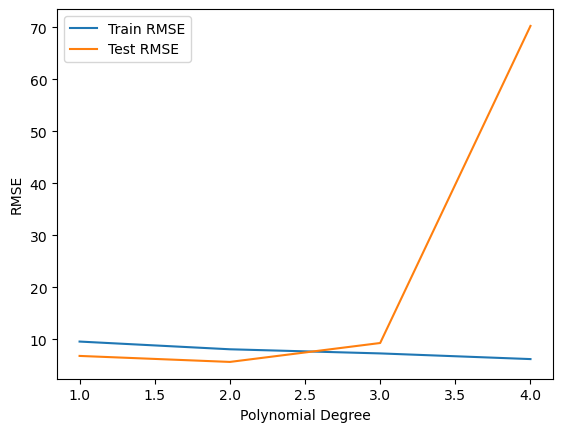

In [32]:
plt.plot(range(1,5), train_RMSE_list[:4],label='Train RMSE')
plt.plot(range(1,5), test_RMSE_list[:4],label='Test RMSE')

plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.legend()